In [92]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt


In [93]:
#working through numpy
def split_dataset(data, val_split=0.15, test_split=0.15, seed=100):
    np.random.seed(seed)
    np.random.shuffle(data)

    total = len(data)
    val_size = int(val_split * total)
    test_size = int(test_split * total)

    test_set  = data[:test_size]
    val_set   = data[test_size:test_size + val_size]
    train_set = data[test_size + val_size:]

    def process(split):
        x = split[:, 1:].T / 255.0
        y = split[:, 0].reshape(1, -1)
        return x, y

    return process(train_set), process(val_set), process(test_set)

In [94]:
current_dir = os.getcwd()
train_csv = pd.read_csv("./files/MNIST/kaggle csv format/mnist_train.csv").values
test_csv  = pd.read_csv("./files/MNIST/kaggle csv format/mnist_test.csv").values
full_data = np.concatenate([train_csv, test_csv], axis=0)

(x_train, y_train), (x_val, y_val), (x_test, y_test) = split_dataset(full_data)

In [95]:
#define all functions
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

def ReLU(x):
    return x * (x > 0)

def dReLU(x):
    return (x > 0).astype(float)

def compute_loss(y_true, y_pred):
    m = y_true.shape[1]
    return -np.sum(y_true * np.log(y_pred + 1e-8)) / m

def one_hot(y, num_classes=10):
    m = y.shape[1]
    oh = np.zeros((num_classes, m))
    oh[y.astype(int), np.arange(m)] = 1
    return oh

def get_accuracy(predictions, labels):
    preds = np.argmax(predictions, axis=0)
    return np.mean(preds == labels.flatten())



In [96]:
def init_params(input_size, hidden_size, output_size):
    #He initialization for weights and biases
    w1 = np.random.randn(hidden_size, input_size) * np.sqrt(2. / input_size)
    b1 = np.zeros((hidden_size, 1))

    w2 = np.random.randn(output_size, hidden_size) * np.sqrt(2. / hidden_size)
    b2 = np.zeros((output_size, 1))

    param = {"w1": w1, "b1": b1, "w2": w2, "b2": b2}

    return param

In [97]:
np.random.seed(100)
param = init_params(784, 64, 10)

In [98]:
def forwardFeed(x, param):
    # retrieve parameters
    w1, b1 = param["w1"], param["b1"]
    w2, b2 = param["w2"], param["b2"]
    z1 = np.dot(w1, x) + b1
    a1 = ReLU(z1)
    z2 = np.dot(w2, a1) + b2
    a2 = softmax(z2)
    return z1, a1, z2, a2

In [99]:
def evaluate(x, y, param):
    _, _, _, out = forwardFeed(x, param)
    return compute_loss(one_hot(y), out), get_accuracy(out, y)

In [100]:
# backpropagation
def backwardFeed(x, y, z1, a1, z2, a2, param, learning_rate):
    m = x.shape[1]
    dz2 = a2 - y
    dw2 = np.dot(dz2, a1.T) / m
    db2 = np.sum(dz2, axis=1, keepdims=True) / m

    da1 = np.dot(param["w2"].T, dz2)
    dz1 = da1 * dReLU(z1)
    dw1 = np.dot(dz1, x.T) / m
    db1 = np.sum(dz1, axis=1, keepdims=True) / m

    param["w1"] -= learning_rate * dw1
    param["b1"] -= learning_rate * db1
    param["w2"] -= learning_rate * dw2
    param["b2"] -= learning_rate * db2
    return param

In [101]:
#training loop
np.random.seed(100)
param = init_params(784, 64, 10)

epochs = 1000
lr = 0.01
y_train_oh = one_hot(y_train)

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(epochs):
    z1, a1, z2, a2 = forwardFeed(x_train, param)
    loss = compute_loss(y_train_oh, a2)
    acc = get_accuracy(a2, y_train)
    param = backwardFeed(x_train, y_train_oh, z1, a1, z2, a2, param, lr)

    val_loss, val_acc = evaluate(x_val, y_val, param)

    train_losses.append(loss)
    train_accuracies.append(acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch}: Train Loss={loss:.4f}, Acc={acc*100:.2f}%, Val Acc={val_acc*100:.2f}%")

Epoch 0: Train Loss=2.4818, Acc=5.63%, Val Acc=5.82%
Epoch 10: Train Loss=2.3597, Acc=8.83%, Val Acc=8.92%
Epoch 20: Train Loss=2.2653, Acc=13.74%, Val Acc=14.09%
Epoch 30: Train Loss=2.1842, Acc=20.79%, Val Acc=21.33%
Epoch 40: Train Loss=2.1097, Acc=29.00%, Val Acc=29.88%
Epoch 50: Train Loss=2.0380, Acc=36.46%, Val Acc=36.98%
Epoch 60: Train Loss=1.9671, Acc=43.32%, Val Acc=43.90%
Epoch 70: Train Loss=1.8963, Acc=49.01%, Val Acc=49.07%
Epoch 80: Train Loss=1.8258, Acc=53.51%, Val Acc=53.79%
Epoch 90: Train Loss=1.7564, Acc=57.21%, Val Acc=57.69%
Epoch 100: Train Loss=1.6885, Acc=60.56%, Val Acc=60.87%
Epoch 110: Train Loss=1.6226, Acc=63.21%, Val Acc=63.65%
Epoch 120: Train Loss=1.5593, Acc=65.49%, Val Acc=66.05%
Epoch 130: Train Loss=1.4990, Acc=67.69%, Val Acc=68.01%
Epoch 140: Train Loss=1.4418, Acc=69.43%, Val Acc=69.53%
Epoch 150: Train Loss=1.3879, Acc=70.91%, Val Acc=70.95%
Epoch 160: Train Loss=1.3373, Acc=72.23%, Val Acc=72.14%
Epoch 170: Train Loss=1.2899, Acc=73.39%, Val 

Final Test Accuracy: 88.45%


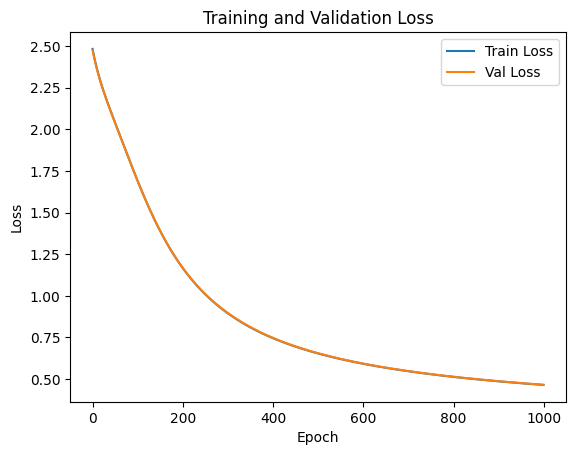

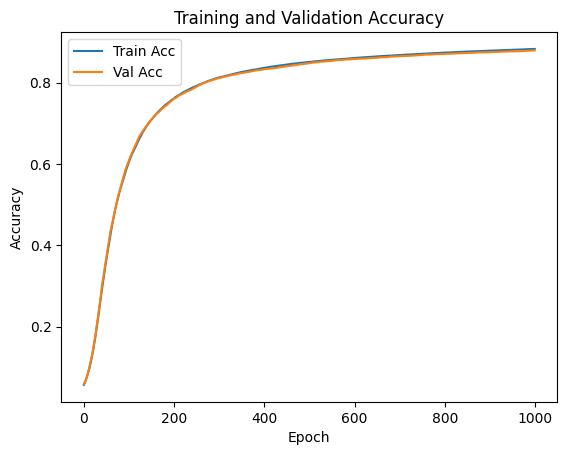

In [102]:
_, _, _, test_preds = forwardFeed(x_test, param)
test_acc = get_accuracy(test_preds, y_test)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

# === Plot Results ===
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

plt.plot(train_accuracies, label="Train Acc")
plt.plot(val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()
